# Seasonal Agriculture Performance Analysis

**A Data Analytics Study of Farm-Level Performance Across Kharif, Rabi and Zaid Seasons**

This notebook explores a dataset of farm-level agricultural records collected across
different states, districts, crops and seasons in India. The goal is to understand how
agricultural performance - yield, production, resource use and profitability - changes
from one season to another, and to surface patterns that could support better seasonal
planning.

*Tools used: Python, Pandas, NumPy, Matplotlib, Seaborn.*
*Scope: Exploratory data analysis and statistical comparison - no machine learning model
is built in this notebook.*


## 1. Why This Problem Matters

Farming outcomes don't stay constant through the year. Rainfall, temperature, humidity,
irrigation practices and even market prices shift with the season, and all of that shows
up in how much a farm produces and how much money it actually makes.

Looking at the raw records alone, it isn't obvious how performance differs across
seasons or why. This notebook sets out to answer that by working directly with the
data - cleaning it, describing it, visualizing it, and comparing seasons, crops, states
and irrigation practices against each other.

**Questions this analysis tries to answer:**
- Does yield/production actually differ by season, and by how much?
- Which crops, states or irrigation methods perform best, and does that change by season?
- What resource-use patterns (water, rainfall, fertilizer) go along with better yield?
- Where does the data show profit and loss, and what seems to explain it?
- What can reasonably be recommended from the evidence, and what can't?


## 2. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
candidate_paths = [
    "seasonal_agriculture_performance_dataset.csv",
    "/content/seasonal_agriculture_performance_dataset.csv",
]
file_path = next((p for p in candidate_paths if os.path.exists(p)), candidate_paths[0])

df = pd.read_csv(file_path)
print(f"Loaded {df.shape[0]} records and {df.shape[1]} columns from '{file_path}'.")


Loaded 4000 records and 28 columns from 'seasonal_agriculture_performance_dataset.csv'.


## 3. Getting to Know the Dataset

In [3]:
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [4]:
df.sample(5, random_state=7)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
2060,SF12061,Gujarat,Erode,Wheat,Kharif,8.57,"1,147.30",31.90,72.50,5.20,7.94,29.10,142.00,29.30,135.40,Sprinkler,58.30,1.28,0.91,0.33,2.83,24959,469713,70634,-399079,3713,0.76,73.90
933,SF10934,Telangana,Krishna,Wheat,Kharif,0.72,792.60,30.90,83.30,7.80,6.88,31.20,150.20,39.40,50.10,Rainfed,244.30,2.71,0.71,2.60,1.87,26051,44873,48715,3842,225,8.31,71.90
378,SF10379,Karnataka,Warangal,Maize,Kharif,10.20,"1,003.00",29.80,85.00,6.20,6.52,36.70,119.00,58.30,69.10,Flood,343.20,4.15,0.78,4.10,41.82,22998,779375,961776,182401,8738,4.79,61.40
2754,SF12755,Andhra Pradesh,Warangal,Pulses,Rabi,11.08,510.20,25.80,54.70,6.60,6.01,29.80,107.40,55.60,136.00,Flood,137.00,8.08,0.66,0.78,8.64,69418,736899,599772,-137127,4918,1.76,29.50
596,SF10597,Andhra Pradesh,Krishna,Rice,Zaid,13.96,89.90,28.50,43.40,9.50,6.83,15.90,79.30,35.50,142.10,Rainfed,222.50,4.67,0.91,1.81,25.27,24312,877099,614364,-262735,9860,2.56,37.90


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

The dataset combines a few different kinds of columns: identifiers (Farm_ID, State,
District), categorical descriptors (Crop, Season, Irrigation_Method), environmental
readings (rainfall, temperature, humidity, soil condition), input/operational measures
(fertilizer, pesticide, seed quality), and outcome measures (yield, production, cost,
revenue, profit, water use). For a seasonal comparison, the outcome measures and the
environmental/operational measures are the ones that matter most - the identifiers are
only useful for counting and grouping.


In [6]:
df.describe()


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [7]:
df.describe(include="object")


/tmp/ipykernel_95/3764884355.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 4. Cleaning Up Before Analysis

Before drawing any conclusions, the data needs a quick health check: are there missing
values, duplicate rows, or obviously wrong entries that would distort the seasonal
comparison?


In [8]:
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_report = pd.DataFrame({"Missing": missing_counts, "Missing %": missing_pct})
missing_report = missing_report[missing_report["Missing"] > 0].sort_values("Missing", ascending=False)
missing_report


,Missing,Missing %
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


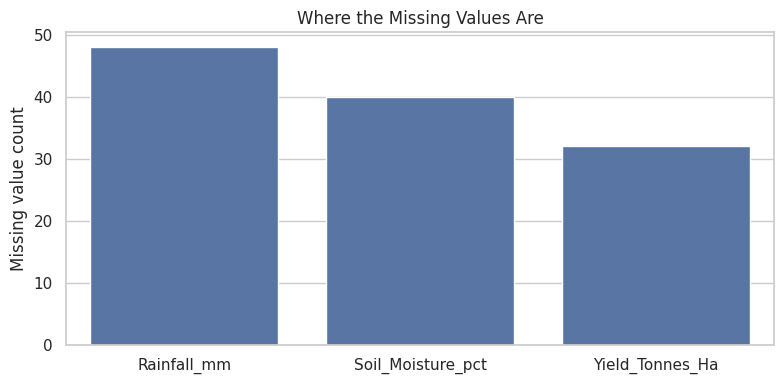

In [9]:
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_report.index, y=missing_report["Missing"])
plt.title("Where the Missing Values Are")
plt.ylabel("Missing value count")
plt.xlabel("")
plt.tight_layout()
plt.show()


Only three columns have any missing data - Rainfall_mm, Soil_Moisture_pct and
Yield_Tonnes_Ha - and each is missing in well under 2% of records. Since these are
continuous numeric measurements with no obvious skew-inducing outliers, a **median fill**
is a reasonable, low-risk way to keep every row usable without distorting the seasonal
averages that this analysis depends on. A mean fill was avoided because a few extreme
values could pull it away from a "typical" reading.


In [10]:
duplicate_rows = df.duplicated().sum()
print("Duplicate rows found:", duplicate_rows)

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", df.shape)


Duplicate rows found: 0
Shape after de-duplication: (4000, 28)


In [11]:
for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
category_cols = df.select_dtypes(include="object").columns.tolist()

print(f"{len(numeric_cols)} numeric columns:", numeric_cols)
print(f"\n{len(category_cols)} categorical columns:", category_cols)


22 numeric columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

6 categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


/tmp/ipykernel_95/2094468934.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_cols = df.select_dtypes(include="object").columns.tolist()


In [13]:
for col in category_cols:
    print(f"{col}: {df[col].nunique()} unique values -> {sorted(df[col].dropna().unique())[:10]}")


Farm_ID: 4000 unique values -> ['SF10001', 'SF10002', 'SF10003', 'SF10004', 'SF10005', 'SF10006', 'SF10007', 'SF10008', 'SF10009', 'SF10010']
State: 8 unique values -> ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
District: 10 unique values -> ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Crop: 8 unique values -> ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season: 3 unique values -> ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method: 4 unique values -> ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


## 5. Describing the Numbers

A quick statistical summary, first across the whole dataset and then split by season, to
see where the spread and the central tendency actually sit.


In [14]:
summary_stats = df[numeric_cols].agg(["mean", "median", "std", "min", "max"]).T
summary_stats["range"] = summary_stats["max"] - summary_stats["min"]
summary_stats


,mean,median,std,min,max,range
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00,14.50
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20","1,315.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70,23.50
Humidity_pct,63.21,63.00,11.96,25.00,95.00,70.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00,7.50
Soil_pH,6.70,6.69,0.64,5.20,8.40,3.20
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00,39.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00,180.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00,105.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00,170.00


In [15]:
season_stats = df.groupby("Season")[["Yield_Tonnes_Ha", "Production_Tonnes",
                                       "Profit_INR", "Water_Used_m3",
                                       "Water_Efficiency_t_per_1000m3",
                                       "Disease_Pest_Risk_pct"]].mean().round(2)
season_stats


,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,
Kharif,5.63,46.31,"178,914.65","6,102.20",5.89,54.47
Rabi,5.04,41.49,"87,689.47","5,846.99",5.19,40.48
Zaid,4.64,38.89,"-24,804.82","6,419.89",4.41,38.22


## 6. Looking at One Variable at a Time

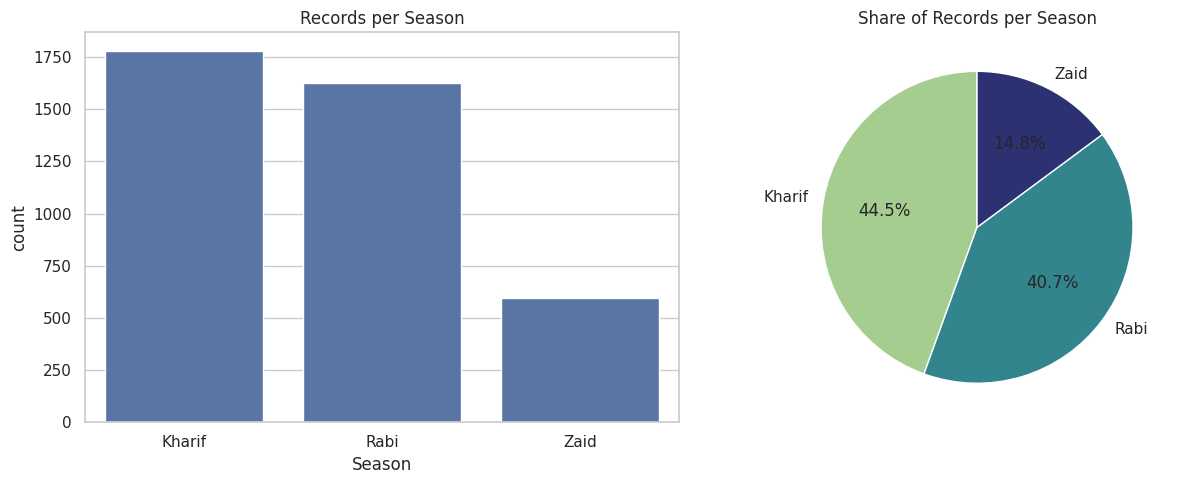

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x="Season", ax=axes[0], order=["Kharif", "Rabi", "Zaid"])
axes[0].set_title("Records per Season")

df["Season"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, ax=axes[1], cmap="crest")
axes[1].set_ylabel("")
axes[1].set_title("Share of Records per Season")

plt.tight_layout()
plt.show()


Kharif accounts for the largest share of records (about 44%), followed by Rabi (about 41%) and
Zaid (about 15%). Zaid being under-represented is worth keeping in mind - its seasonal
averages later on will be based on a noticeably smaller sample.


/tmp/ipykernel_95/1379546032.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, palette="crest")


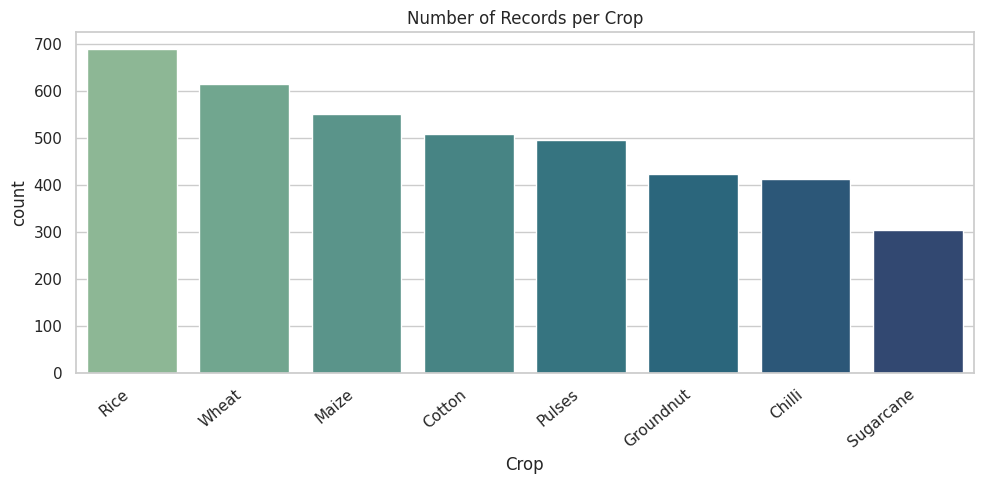

In [17]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, palette="crest")
plt.title("Number of Records per Crop")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


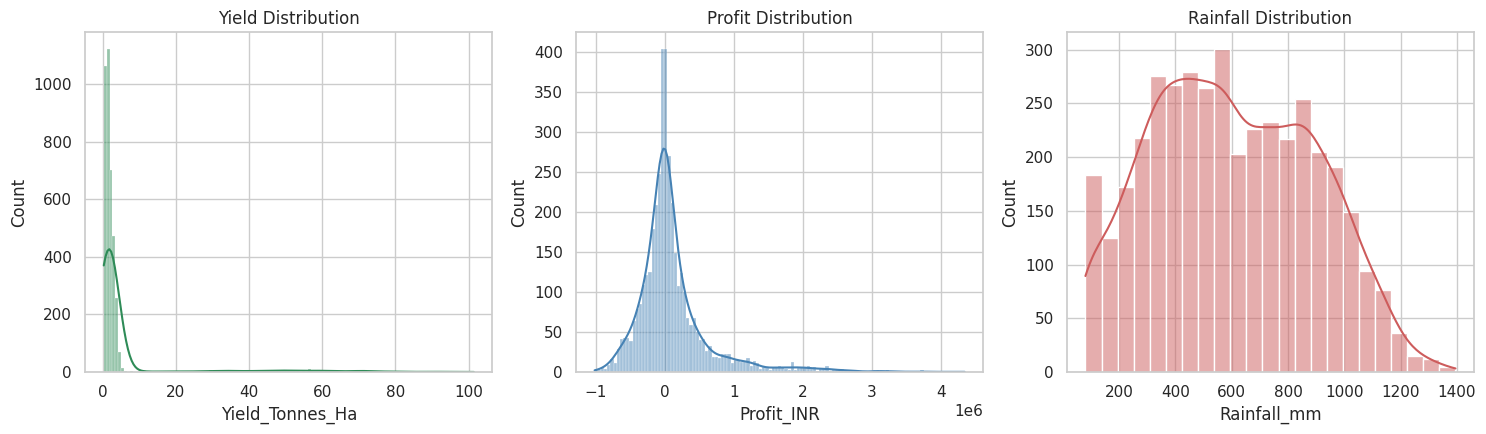

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.histplot(df["Yield_Tonnes_Ha"], kde=True, ax=axes[0], color="seagreen")
axes[0].set_title("Yield Distribution")

sns.histplot(df["Profit_INR"], kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Profit Distribution")

sns.histplot(df["Rainfall_mm"], kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Rainfall Distribution")

plt.tight_layout()
plt.show()


Yield is right-skewed - most farms cluster at modest yields with a long tail from a
handful of very high performers (this is largely the Sugarcane crop, whose yield is
measured on a very different scale to grains). Profit is roughly centered near zero with
a wide spread in both directions, hinting that a meaningful share of farm records are
loss-making. Rainfall looks close to a normal/bell-shaped spread.


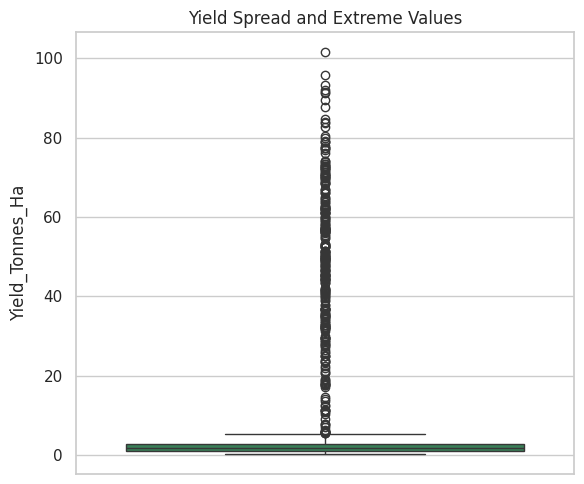

In [19]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=df["Yield_Tonnes_Ha"], color="seagreen")
plt.title("Yield Spread and Extreme Values")
plt.tight_layout()
plt.show()


## 7. Checking for Unusual Values

Rather than deleting anything unusual on sight, the approach here is to flag potential
outliers with the IQR method and judge, column by column, whether they look like
legitimate high/low performers (e.g. Sugarcane's naturally huge yield-per-hectare) or
something that looks like a data problem.


In [20]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

rows = []
for col in numeric_cols:
    count, lower, upper = iqr_outlier_count(df[col])
    rows.append({"Column": col, "Outliers": count,
                 "Outlier %": round(count / len(df) * 100, 2),
                 "Lower bound": round(lower, 2), "Upper bound": round(upper, 2)})

outlier_report = pd.DataFrame(rows).sort_values("Outliers", ascending=False)
outlier_report


,Column,Outliers,Outlier %,Lower bound,Upper bound
18,Profit_INR,404,10.10,"-696,111.00","763,567.00"
14,Production_Tonnes,333,8.33,-23.98,53.36
20,Water_Efficiency_t_per_1000m3,322,8.05,-3.57,10.38
13,Yield_Tonnes_Ha,302,7.55,-1.62,5.50
19,Water_Used_m3,276,6.90,"-6,072.75","16,171.25"
17,Revenue_INR,240,6.00,"-736,519.00","1,780,911.00"
9,Potassium_kg_ha,32,0.80,30.10,179.70
4,Sunlight_Hours_Day,26,0.65,4.35,10.35
8,Phosphorus_kg_ha,16,0.40,11.40,104.20
10,Fertilizer_kg_ha,15,0.38,19.14,352.04


Yield_Tonnes_Ha and Production_Tonnes show up with the largest outlier counts, but
that's expected here - Sugarcane yields are naturally an order of magnitude higher than
grains like Wheat or Rice, so this looks like a genuine crop effect rather than bad data.
None of these values are kept out of the analysis; they're just noted so that later
comparisons (like crop-wise averages) are read with this in mind.


## 8. Comparing Two Variables at a Time

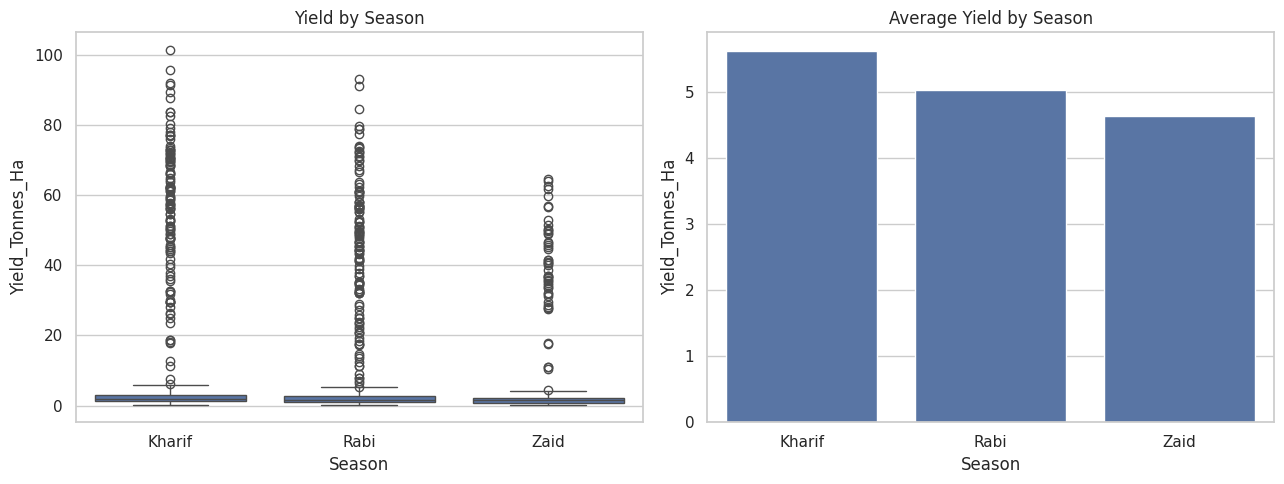

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", order=["Kharif", "Rabi", "Zaid"], ax=axes[0])
axes[0].set_title("Yield by Season")

sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", order=["Kharif", "Rabi", "Zaid"], errorbar=None, ax=axes[1])
axes[1].set_title("Average Yield by Season")

plt.tight_layout()
plt.show()


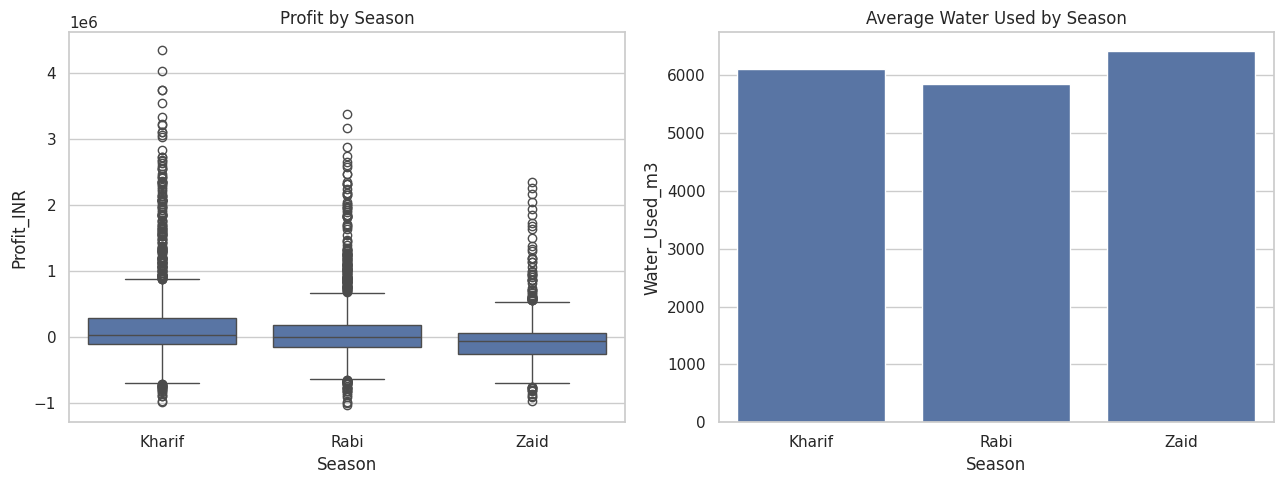

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Season", y="Profit_INR", order=["Kharif", "Rabi", "Zaid"], ax=axes[0])
axes[0].set_title("Profit by Season")

sns.barplot(data=df, x="Season", y="Water_Used_m3", order=["Kharif", "Rabi", "Zaid"], errorbar=None, ax=axes[1])
axes[1].set_title("Average Water Used by Season")

plt.tight_layout()
plt.show()


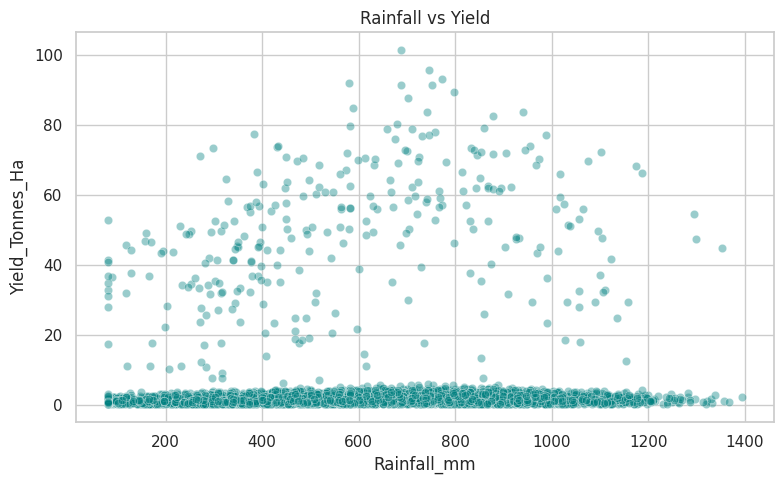

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.4, color="teal")
plt.title("Rainfall vs Yield")
plt.tight_layout()
plt.show()


The scatter of rainfall against yield is fairly flat - more rain does not visibly
translate into more yield in this dataset. That's a useful early signal that whatever is
driving yield differences across seasons, it probably isn't rainfall by itself.


/tmp/ipykernel_95/2674509565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha",


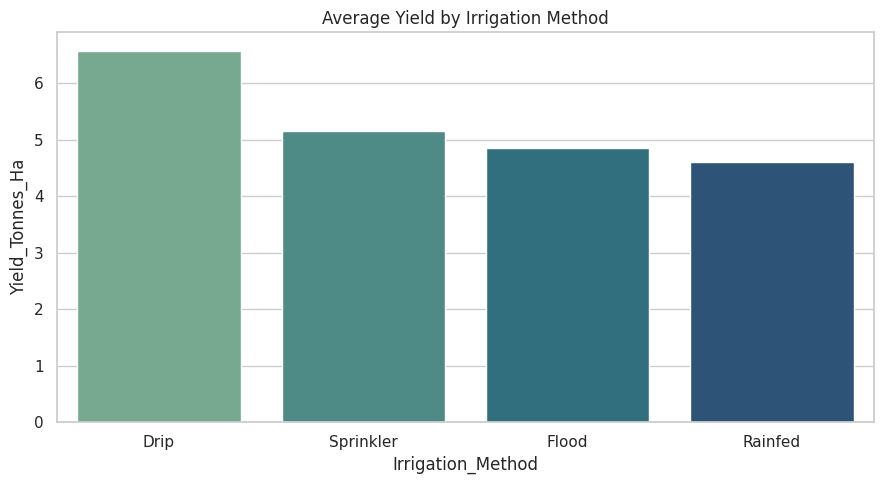

In [24]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha",
            order=df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False).index,
            errorbar=None, palette="crest")
plt.title("Average Yield by Irrigation Method")
plt.tight_layout()
plt.show()


## 9. Looking at Several Variables Together

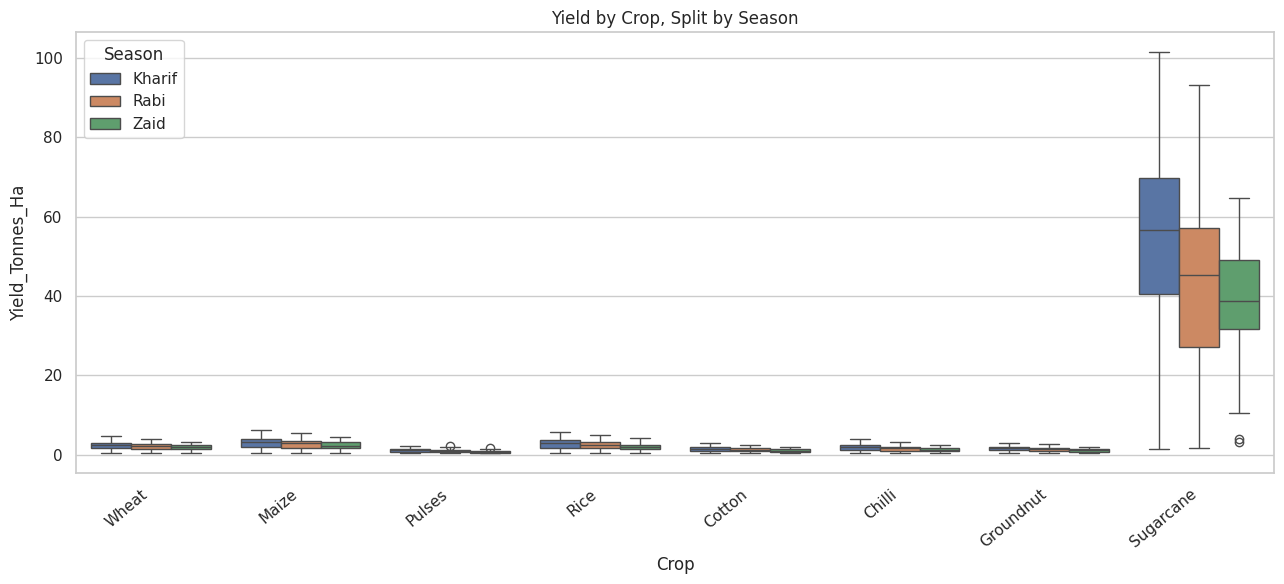

In [25]:
plt.figure(figsize=(13, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Crop, Split by Season")
plt.xticks(rotation=40, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


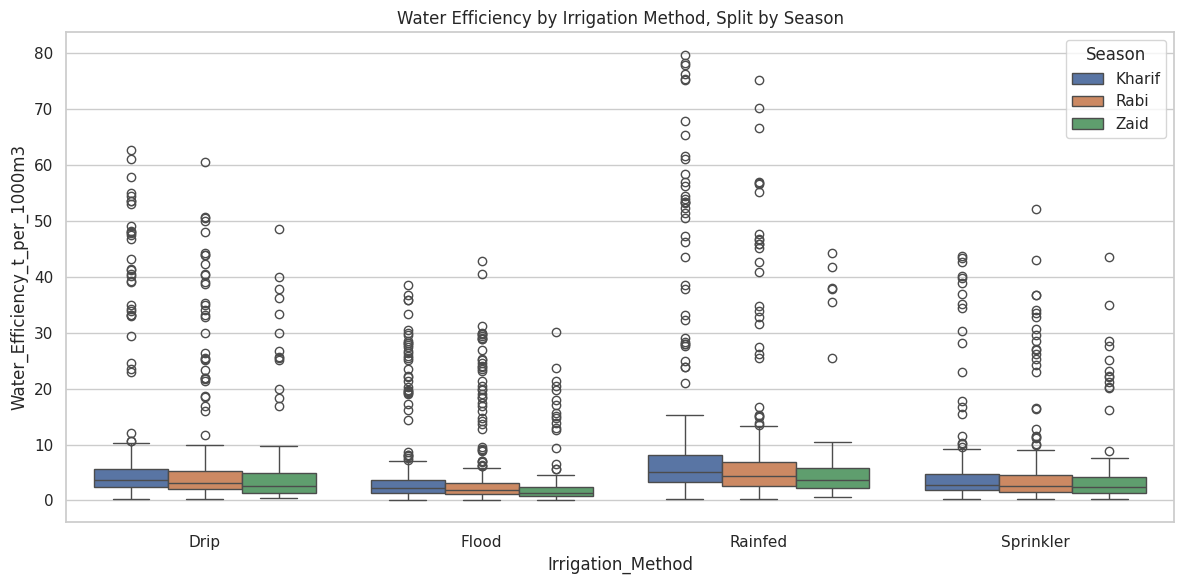

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Water_Efficiency_t_per_1000m3", hue="Season")
plt.title("Water Efficiency by Irrigation Method, Split by Season")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


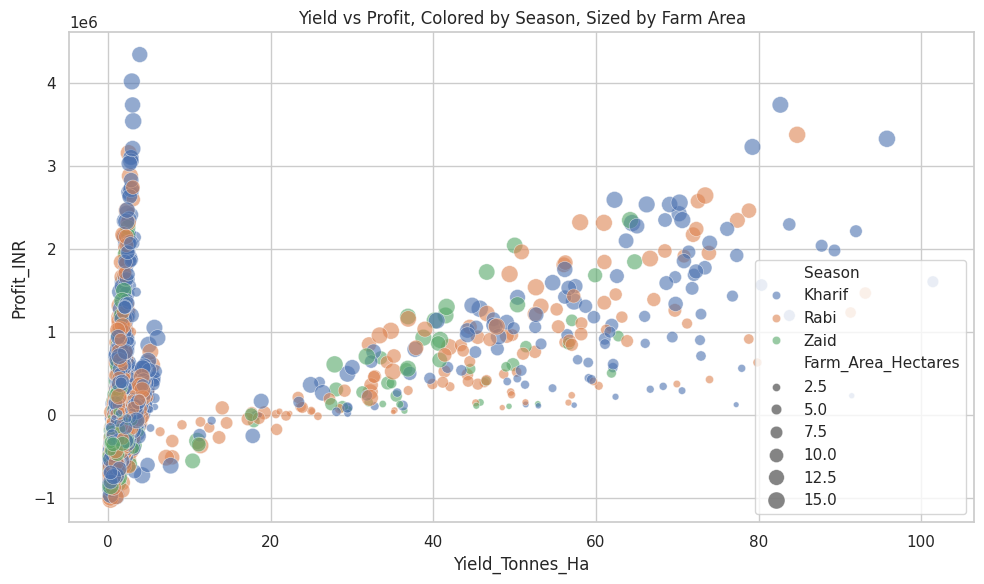

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Yield_Tonnes_Ha", y="Profit_INR", hue="Season",
                size="Farm_Area_Hectares", sizes=(15, 150), alpha=0.6)
plt.title("Yield vs Profit, Colored by Season, Sized by Farm Area")
plt.tight_layout()
plt.show()


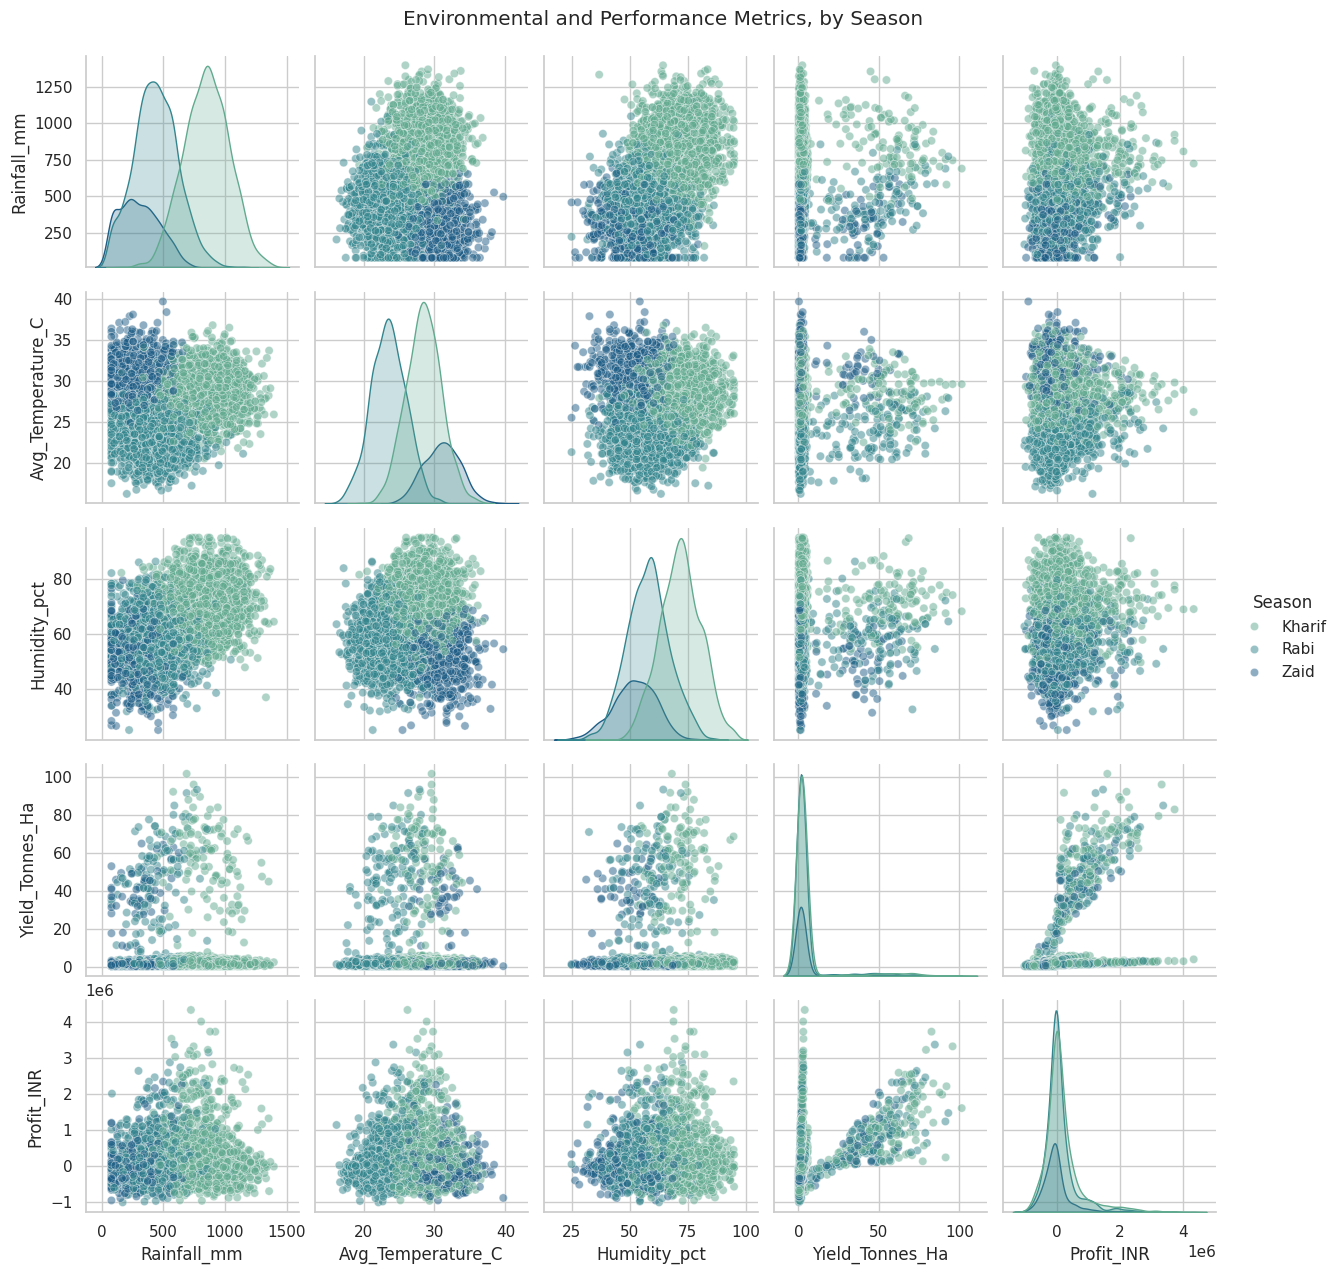

In [28]:
key_metrics = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
                "Yield_Tonnes_Ha", "Profit_INR", "Season"]
sns.pairplot(df[key_metrics], hue="Season", plot_kws={"alpha": 0.5}, palette="crest")
plt.suptitle("Environmental and Performance Metrics, by Season", y=1.02)
plt.show()


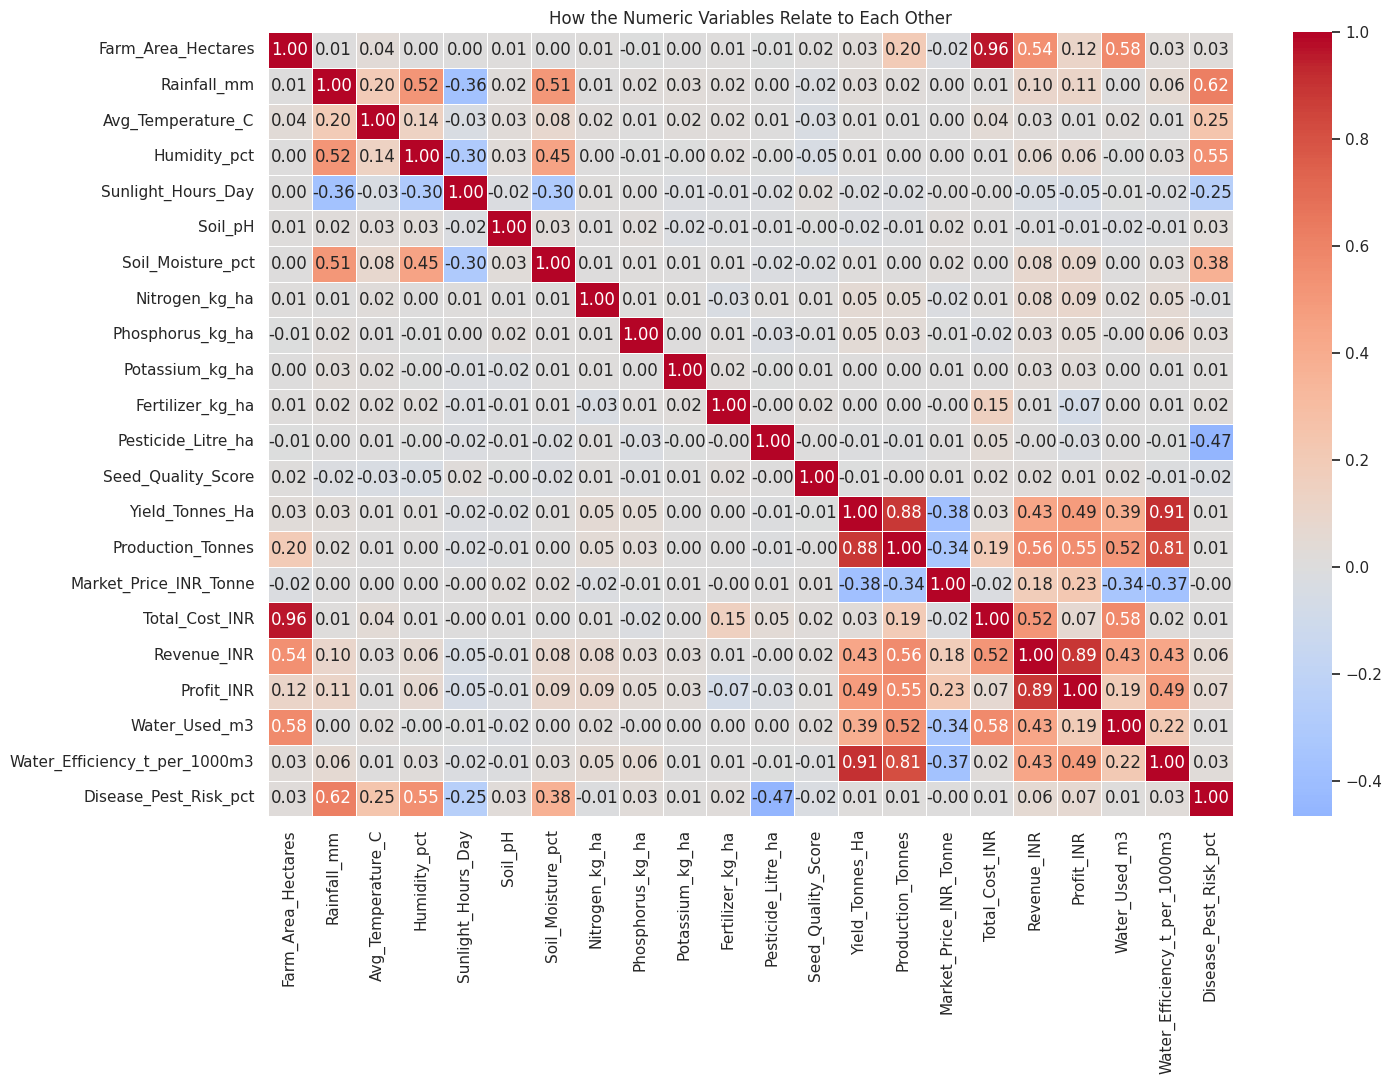

In [29]:
plt.figure(figsize=(15, 11))
corr_matrix = df[numeric_cols].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4)
plt.title("How the Numeric Variables Relate to Each Other")
plt.tight_layout()
plt.show()


In [30]:
corr_matrix["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(ascending=False)

Water_Efficiency_t_per_1000m3    0.91
Production_Tonnes                0.88
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Rainfall_mm                      0.03
Total_Cost_INR                   0.03
Farm_Area_Hectares               0.03
Disease_Pest_Risk_pct            0.01
Humidity_pct                     0.01
Soil_Moisture_pct                0.01
Avg_Temperature_C                0.01
Potassium_kg_ha                  0.00
Fertilizer_kg_ha                 0.00
Seed_Quality_Score              -0.01
Pesticide_Litre_ha              -0.01
Sunlight_Hours_Day              -0.02
Soil_pH                         -0.02
Market_Price_INR_Tonne          -0.38
Name: Yield_Tonnes_Ha, dtype: float64

Water_Efficiency_t_per_1000m3 and Production_Tonnes are, by far, the strongest
correlates of yield (both above 0.85). Rainfall_mm, Farm_Area_Hectares` and most soil
and input variables (fertilizer, pesticide, seed quality) show almost no linear
relationship with yield at all in this dataset. That's a somewhat counter-intuitive
finding worth carrying into the seasonal comparison: whatever separates a good season
from a bad one, it looks more tied to *how efficiently water is used* than to rainfall
volume itself.


## 10. Putting the Seasons Side by Side

This section pulls the threads above together into direct season-to-season comparisons
on the metrics that matter most for the project's core question.


In [31]:
season_overview = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
).round(2).reindex(["Kharif", "Rabi", "Zaid"])
season_overview


,Records,Avg_Yield,Total_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Season,,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65","6,102.20",5.89,54.47
Rabi,1627,5.04,"67,498.88","87,689.47","5,846.99",5.19,40.48
Zaid,594,4.64,"23,098.35","-24,804.82","6,419.89",4.41,38.22


In [32]:
top_crop_per_season = (
    df.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"].mean()
      .groupby(level=0).idxmax()
      .apply(lambda x: x[1])
)
print("Highest-yielding crop, by season:")
print(top_crop_per_season)


Highest-yielding crop, by season:
Season
Kharif    Sugarcane
Rabi      Sugarcane
Zaid      Sugarcane
Name: Yield_Tonnes_Ha, dtype: str


## 11. Three Follow-Up Questions Worth Digging Into

The exploration above raised a few specific questions that deserve a closer look before
drawing conclusions.


### 11.1 Does the best irrigation method stay the best in every season, or does the
ranking flip?


In [33]:
irrigation_by_season = (
    df.groupby(["Season", "Irrigation_Method"])
      .agg(Avg_Yield=("Yield_Tonnes_Ha", "mean"),
           Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"))
      .round(2)
)
irrigation_by_season


Avg_Yield  Avg_Water_Efficiency
Season Irrigation_Method                                 
Kharif Drip                    7.26                  6.80
       Flood                   4.98                  3.64
       Rainfed                 5.70                  8.85
       Sprinkler               4.66                  4.62
Rabi   Drip                    6.11                  6.05
       Flood                   5.06                  3.48
       Rainfed                 3.93                  6.87
       Sprinkler               5.31                  4.64
Zaid   Drip                    5.85                  5.30
       Flood                   3.98                  2.73
       Rainfed                 3.06                  5.48
       Sprinkler               6.14                  4.86

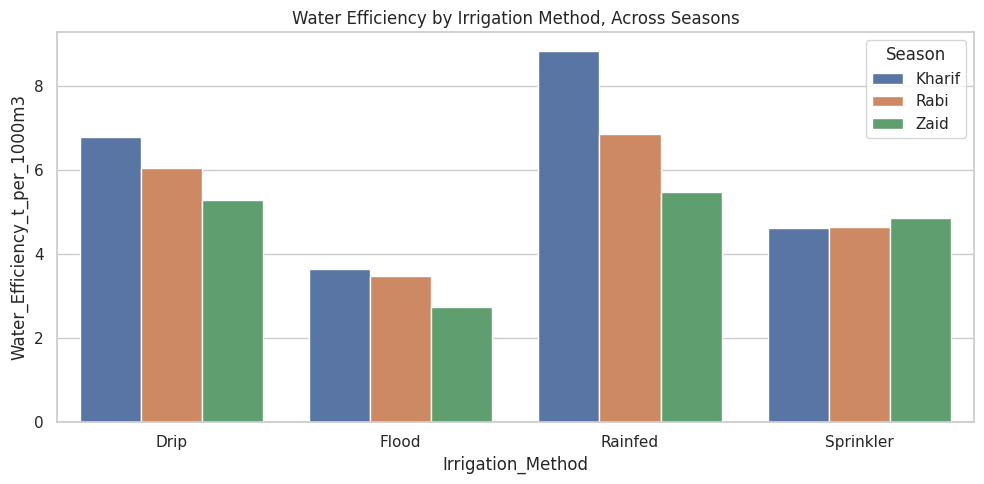

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Water_Efficiency_t_per_1000m3",
            hue="Season", errorbar=None)
plt.title("Water Efficiency by Irrigation Method, Across Seasons")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


Drip irrigation comes out on top in every single season, both for yield and for water
efficiency - it never gets overtaken by Sprinkler, Flood or Rainfed methods regardless of
season. Flood irrigation, despite using the most water, converts it to yield the least
efficiently. This is one of the more actionable patterns in the whole dataset: switching
away from Flood irrigation looks beneficial *regardless of which season a farm is in.*


### 11.2 Is profitability mostly a seasonal story, or a regional one?


In [35]:
state_profit = df.groupby("State").agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean")
).round(2).sort_values("Avg_Profit", ascending=False)
state_profit


,Avg_Yield,Avg_Profit
State,,
Punjab,6.12,"136,025.64"
Maharashtra,5.02,"135,428.86"
Karnataka,5.69,"119,422.34"
Tamil Nadu,4.88,"117,744.75"
Gujarat,5.66,"117,568.24"
Telangana,5.04,"108,829.62"
Madhya Pradesh,4.99,"86,840.76"
Andhra Pradesh,4.63,"73,453.53"


/tmp/ipykernel_95/271017152.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="State", y="Profit_INR", order=state_profit.index, errorbar=None, palette="crest")


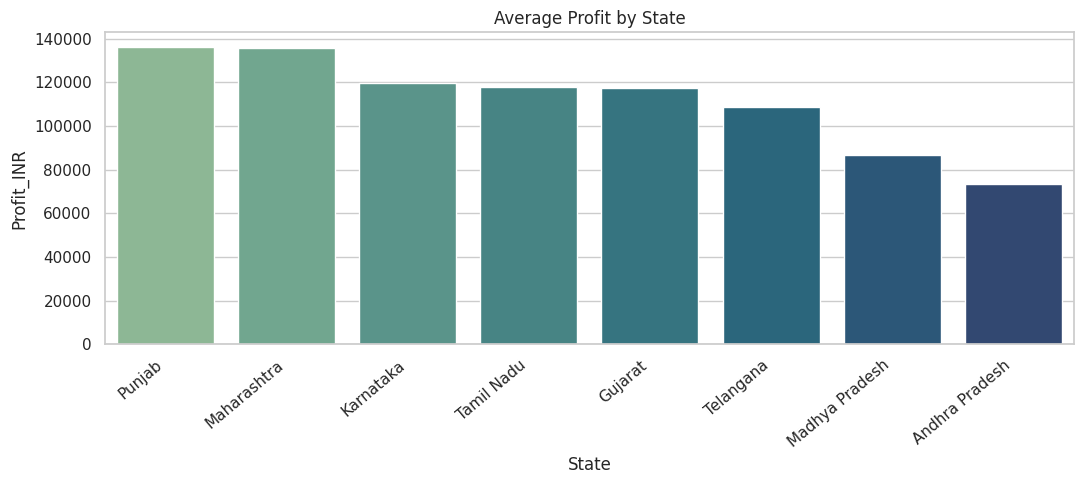

In [36]:
plt.figure(figsize=(11, 5))
sns.barplot(data=df, x="State", y="Profit_INR", order=state_profit.index, errorbar=None, palette="crest")
plt.title("Average Profit by State")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


Profit differs a lot by state - Punjab and Maharashtra sit well above Andhra Pradesh and
Madhya Pradesh - and this gap doesn't disappear once season is accounted for. That
suggests profitability in this dataset is shaped by *both* season and geography, not by
season alone.


### 11.3 Which crops are actually profitable, and does that change across seasons?


In [37]:
df["Profit_Margin_pct"] = (df["Profit_INR"] / df["Revenue_INR"]) * 100

crop_margin = df.groupby("Crop")["Profit_Margin_pct"].mean().round(2).sort_values(ascending=False)
season_margin = df.groupby("Season")["Profit_Margin_pct"].mean().round(2)

print("Average profit margin (%) by crop:")
print(crop_margin)
print("\nAverage profit margin (%) by season:")
print(season_margin)


Average profit margin (%) by crop:
Crop
Chilli       33.78
Sugarcane    27.35
Cotton       -8.23
Groundnut   -28.66
Pulses      -36.48
Maize       -81.54
Wheat       -91.70
Rice        -99.37
Name: Profit_Margin_pct, dtype: float64

Average profit margin (%) by season:
Season
Kharif   -38.64
Rabi     -44.27
Zaid     -69.35
Name: Profit_Margin_pct, dtype: float64


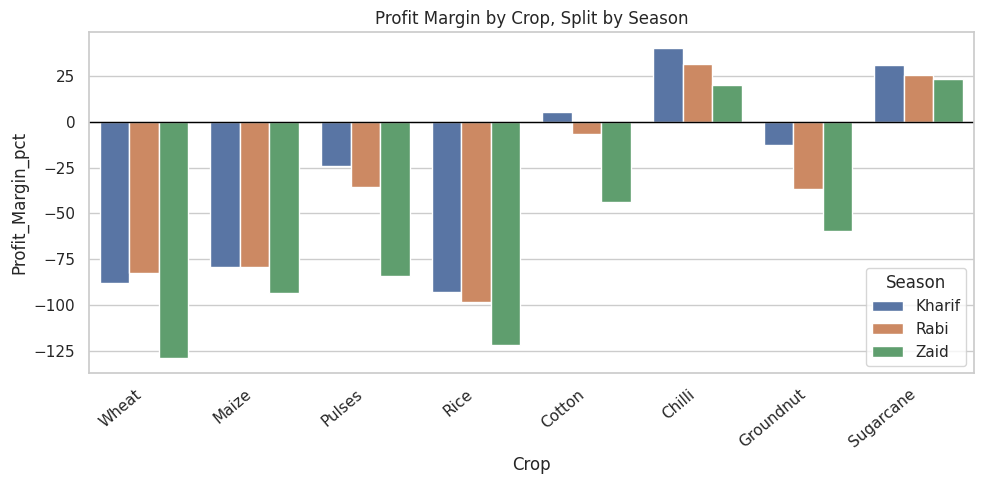

In [38]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Crop", y="Profit_Margin_pct", hue="Season", errorbar=None)
plt.axhline(0, color="black", linewidth=1)
plt.title("Profit Margin by Crop, Split by Season")
plt.xticks(rotation=40, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


High-value crops - Sugarcane and Chilli in particular - hold on to a positive profit
margin, while staple grains (Wheat, Rice, Maize) run a negative margin on average in
every season. This points to crop choice / cost structure being at least as important as
the season itself when it comes to whether a farm record actually turns a profit.


## 12. What the Data Is Actually Telling Us

Pulling everything above together into the findings that matter most:


**1. Kharif is the strongest season for yield and volume, but the riskiest for pests.**
Kharif has the highest average yield (about 5.6 t/ha) and total production of the three
seasons, and also the highest average disease/pest risk (about 54%, vs about 38-40% in Rabi and
Zaid). The upside and the risk seem to travel together in this dataset.

**2. Zaid is the weakest season on almost every measure.**
Lowest average yield (about 4.6 t/ha) and the most negative average profit margin of the
three seasons. It's also the smallest season by record count (594 of 4,000), so its
averages should be treated with a bit more caution than Kharif's or Rabi's.

**3. Water efficiency explains far more of the yield story than rainfall does.**
Water efficiency correlates with yield at roughly 0.9; rainfall correlates with yield at
roughly 0.03. Whatever makes a season or a farm perform well, it isn't simply "how much
it rained."

**4. Irrigation method matters more than season for yield performance.**
Drip irrigation posts the best yield and water efficiency in Kharif, Rabi and Zaid alike
- it's never overtaken by Flood, Sprinkler or Rainfed methods in any season.

**5. Regional differences in profit are real and don't wash out once season is
considered.**
Punjab and Maharashtra average noticeably higher profit than Andhra Pradesh and Madhya
Pradesh, and this gap shows up across seasons rather than in just one.

**6. Crop choice drives whether a record is profitable at all.**
Sugarcane and Chilli keep a positive average profit margin; Wheat, Rice and Maize run
negative margins on average, in every season. Season alone does not decide profitability.

**7. Farm size scales total output but not efficiency.**
Farm area correlates strongly with total production but barely at all with yield per
hectare - bigger farms aren't automatically more efficient per unit of land.

**8. Environmental variables (temperature, humidity, soil pH) show weak individual
correlation with yield.**
None of the single environmental readings correlate strongly with yield on their own,
suggesting yield outcomes in this dataset are driven by a mix of factors (especially
water management) rather than any one weather variable.

*A caveat that applies to all of the above: this is a single, cross-sectional dataset.
The patterns above are associations found in the data, not proof of cause and effect.*


## 13. What This Would Suggest, If Acted On

- **Push drip irrigation adoption first, especially where Flood irrigation is still
used.** It's the single most consistent, season-independent performance gain in the
data.
- **Treat Zaid-season farming as higher-risk** and consider extra support (cost buffers,
insurance, or crop substitution) for farms cultivating in that window.
- **Concentrate pest/disease monitoring resources around Kharif**, when risk is highest,
rather than spreading them evenly across the year.
- **Support crop diversification toward higher-margin crops** where soil and climate
allow, since staple grains show negative margins on average in this data.
- **Direct extra support to lower-profit states** (e.g. Andhra Pradesh, Madhya Pradesh)
independently of season, since the profit gap persists across all three seasons.

*These are data-backed directions, not final decisions - they'd need to be checked
against real agronomic and financial constraints (like the cost of switching irrigation
infrastructure) before being acted on.*


## 14. Conclusion

Across 4,000 farm records spanning three seasons, eight crops and eight states, the
clearest story is that **season is only part of the picture**. Kharif brings the best
yields but the highest pest risk; Zaid is the weakest season for both output and profit.
But irrigation method, crop choice and state consistently explain as much - sometimes
more - of the difference in performance and profitability as season does on its own.

The most useful, actionable finding is the irrigation-method comparison: Drip irrigation
outperforms every alternative in every season, which makes it a rare case of a clear,
practical lever rather than just an observation about the weather.

This analysis is limited by being a single snapshot of data (no multi-year trend), by
Zaid's smaller sample size, and by not knowing the real-world cost of implementing any of
the suggested changes. A natural next step would be to repeat this analysis across
multiple years to see whether these seasonal and regional patterns hold up over time.
